In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
 
print("Imports done ✓")

Imports done ✓


In [2]:
# Load the train/test files we saved in Phase 3
train = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\train.csv')
test  = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\test.csv')
 
# Separate features (X) and target (y)
# y is already log-transformed (we did that in Phase 3)
y_train = train['SalePrice'].values   # .values converts to numpy array
y_test  = test['SalePrice'].values
 
X_train = train.drop(columns=['SalePrice'])
X_test  = test.drop(columns=['SalePrice'])
 
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nAll available columns:\n{list(X_train.columns)}")

Train: (2341, 188)  |  Test: (586, 188)

All available columns:
['MS SubClass', 'Lot Frontage', 'Lot Area', 'Land Slope', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating QC', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', 'Screen Porch', 'Fence', 'Mo Sold', 'Yr Sold', 'MS Zoning_C (all)', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Alley_None', 'Alley_Pave', 'Lot Shape_IR2', 'Lot Shape_IR3', 'Lot Shape_Reg', 'Land

In [3]:
feature = 'Overall Qual'
 
# Extract just that one column as a 1D array
x_train = X_train[feature].values
x_test  = X_test[feature].values
 
print(f"Feature selected : {feature}")
print(f"x_train shape    : {x_train.shape}")
print(f"y_train shape    : {y_train.shape}")

Feature selected : Overall Qual
x_train shape    : (2341,)
y_train shape    : (2341,)


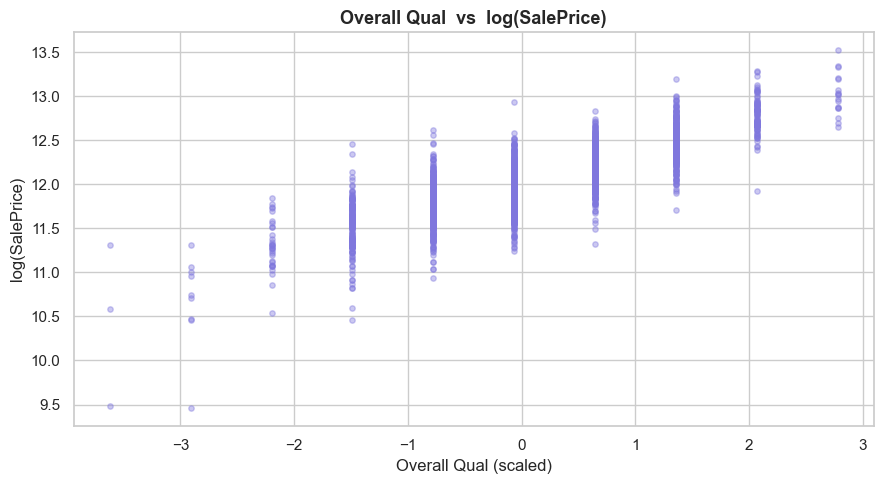

If you see a clear upward trend → linear regression is a good fit ✓


In [4]:
# Always plot your X vs y before building any model.
# You want to see a roughly linear pattern.
 
plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, alpha=0.4, color='#7F77DD', s=15)
plt.xlabel(f'{feature} (scaled)')
plt.ylabel('log(SalePrice)')
plt.title(f'{feature}  vs  log(SalePrice)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
print("If you see a clear upward trend → linear regression is a good fit ✓")

In [5]:

#  OLS finds the BEST line by solving a direct math formula.
#  "Best" means: minimise the sum of squared errors (residuals).
#
#  Formula:
#    β₁ (slope)     = Σ (xᵢ - x̄)(yᵢ - ȳ)  /  Σ (xᵢ - x̄)²
#    β₀ (intercept) = ȳ  -  β₁ * x̄
#
#  No loops, no iterations — one calculation and you're done.
# ────────────────────────────────────────────────────────────────
 
# Step 1 — Compute means
x_mean = np.mean(x_train)   # x̄
y_mean = np.mean(y_train)   # ȳ
 
# Step 2 — Compute slope β₁
#   numerator   = Σ (xᵢ - x̄)(yᵢ - ȳ)
#   denominator = Σ (xᵢ - x̄)²
numerator   = np.sum((x_train - x_mean) * (y_train - y_mean))
denominator = np.sum((x_train - x_mean) ** 2)
 
beta1_ols = numerator / denominator   # slope
 
# Step 3 — Compute intercept β₀
beta0_ols = y_mean - beta1_ols * x_mean
 
print("── OLS Results ──────────────────────────────")
print(f"  Intercept  β₀ = {beta0_ols:.6f}")
print(f"  Slope      β₁ = {beta1_ols:.6f}")
print()
print(f"  Interpretation: for every 1-unit increase in '{feature}',")
print(f"  log(SalePrice) goes up by {beta1_ols:.4f}")
 

── OLS Results ──────────────────────────────
  Intercept  β₀ = 12.020002
  Slope      β₁ = 0.337062

  Interpretation: for every 1-unit increase in 'Overall Qual',
  log(SalePrice) goes up by 0.3371


In [6]:
#── CELL 6 — OLS Predictions & Metrics ──────────────────────────
#
#  Prediction formula:  ŷ = β₀ + β₁ * x
#
#  Metrics we compute:
#    MSE  = Mean Squared Error       = average of (actual - predicted)²
#    RMSE = Root Mean Squared Error  = √MSE  (same unit as y)
#    R²   = how much variance in y our model explains (0 to 1)
# ────────────────────────────────────────────────────────────────
 
# Predict on train and test
y_pred_train_ols = beta0_ols + beta1_ols * x_train
y_pred_test_ols  = beta0_ols + beta1_ols * x_test
 
# --- Compute metrics from scratch ---
 
# MSE: average squared difference between actual and predicted
mse_train_ols  = np.mean((y_train - y_pred_train_ols) ** 2)
mse_test_ols   = np.mean((y_test  - y_pred_test_ols)  ** 2)
 
# RMSE: square root of MSE
rmse_train_ols = np.sqrt(mse_train_ols)
rmse_test_ols  = np.sqrt(mse_test_ols)
 
# R² from scratch:
#   SS_res = Σ (actual - predicted)²   ← residual sum of squares
#   SS_tot = Σ (actual - mean)²         ← total sum of squares
#   R²     = 1 - (SS_res / SS_tot)
ss_res_ols = np.sum((y_test - y_pred_test_ols) ** 2)
ss_tot     = np.sum((y_test - np.mean(y_test))  ** 2)
r2_ols     = 1 - (ss_res_ols / ss_tot)
 
print("── OLS Metrics ──────────────────────────────")
print(f"  Train RMSE : {rmse_train_ols:.4f}")
print(f"  Test  RMSE : {rmse_test_ols:.4f}")
print(f"  Test  R²   : {r2_ols:.4f}")
print()
print(f"  R² = {r2_ols:.2%} of price variance explained by '{feature}' alone")

── OLS Metrics ──────────────────────────────
  Train RMSE : 0.2276
  Test  RMSE : 0.2311
  Test  R²   : 0.7026

  R² = 70.26% of price variance explained by 'Overall Qual' alone


In [7]:
# ── CELL 7 — METHOD 2 : Gradient Descent from Scratch ───────────
#
#  Instead of a direct formula, Gradient Descent starts with a
#  random guess and slowly improves it step by step.
#
#  At each step:
#    1. Make predictions with current β₀, β₁
#    2. Compute error (how wrong we are)
#    3. Compute gradient (which direction to move)
#    4. Update β₀ and β₁ by a small amount (learning rate α)
#    5. Repeat until error stops improving
#
#  Cost function:  J = (1/2m) Σ (ŷᵢ - yᵢ)²
#  Update rules:
#    β₀ = β₀ - α * (1/m) Σ (ŷᵢ - yᵢ)
#    β₁ = β₁ - α * (1/m) Σ (ŷᵢ - yᵢ) * xᵢ
# ────────────────────────────────────────────────────────────────
 
# Hyperparameters — you choose these yourself
learning_rate = 0.01    # α : how big each step is (too big = overshoots, too small = slow)
n_iterations  = 2000    # how many times to update
 
# Starting point — begin with zeros
beta0_gd = 0.0
beta1_gd = 0.0
 
m = len(x_train)        # number of training samples
 
cost_history = []       # we'll track cost at each step to plot later
 
for i in range(n_iterations):
 
    # Step 1 — Predict with current parameters
    y_pred = beta0_gd + beta1_gd * x_train
 
    # Step 2 — Compute error (residual)
    error = y_pred - y_train          # shape: (m,)
 
    # Step 3 — Compute cost (average squared error)
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    cost_history.append(cost)
 
    # Step 4 — Compute gradients
    grad_beta0 = (1 / m) * np.sum(error)           # partial derivative w.r.t β₀
    grad_beta1 = (1 / m) * np.sum(error * x_train) # partial derivative w.r.t β₁
 
    # Step 5 — Update parameters (move in the opposite direction of gradient)
    beta0_gd = beta0_gd - learning_rate * grad_beta0
    beta1_gd = beta1_gd - learning_rate * grad_beta1
 
print("── Gradient Descent Results ─────────────────")
print(f"  Intercept  β₀ = {beta0_gd:.6f}")
print(f"  Slope      β₁ = {beta1_gd:.6f}")
 

── Gradient Descent Results ─────────────────
  Intercept  β₀ = 12.020002
  Slope      β₁ = 0.337062


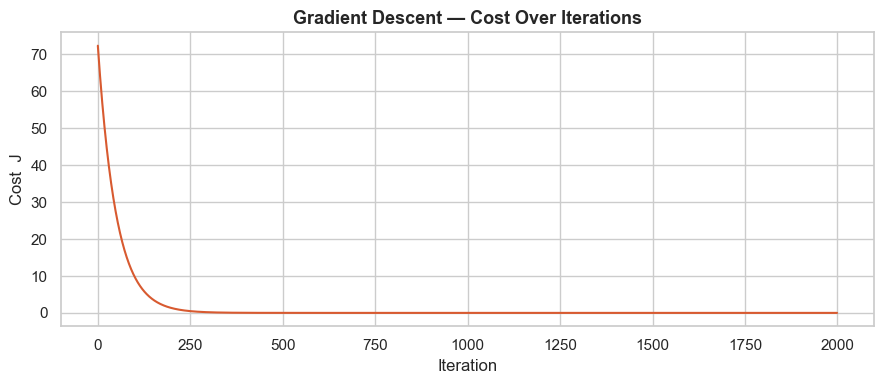

Final cost after 2000 iterations: 0.025898


In [8]:

# This shows the cost (error) going down as GD learns.
# A smooth downward curve = GD is working correctly.
# If it goes up or zigzags → learning rate is too high.
 
plt.figure(figsize=(9, 4))
plt.plot(cost_history, color='#D85A30', linewidth=1.5)
plt.xlabel('Iteration')
plt.ylabel('Cost  J')
plt.title('Gradient Descent — Cost Over Iterations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\10_gd_cost_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
print(f"Final cost after {n_iterations} iterations: {cost_history[-1]:.6f}")
 

In [9]:
y_pred_train_gd = beta0_gd + beta1_gd * x_train
y_pred_test_gd  = beta0_gd + beta1_gd * x_test
 
rmse_train_gd = np.sqrt(np.mean((y_train - y_pred_train_gd) ** 2))
rmse_test_gd  = np.sqrt(np.mean((y_test  - y_pred_test_gd)  ** 2))
 
ss_res_gd = np.sum((y_test - y_pred_test_gd) ** 2)
r2_gd     = 1 - (ss_res_gd / ss_tot)
 
print("── Gradient Descent Metrics ─────────────────")
print(f"  Train RMSE : {rmse_train_gd:.4f}")
print(f"  Test  RMSE : {rmse_test_gd:.4f}")
print(f"  Test  R²   : {r2_gd:.4f}")

── Gradient Descent Metrics ─────────────────
  Train RMSE : 0.2276
  Test  RMSE : 0.2311
  Test  R²   : 0.7026


In [10]:
#We now use sklearn to double-check our from-scratch results.
# The numbers should match (or be very close).
 
# sklearn expects X to be 2D, so we reshape from (n,) to (n, 1)
x_train_2d = x_train.reshape(-1, 1)
x_test_2d  = x_test.reshape(-1, 1)
 
sk_model = LinearRegression()
sk_model.fit(x_train_2d, y_train)
 
y_pred_sk = sk_model.predict(x_test_2d)
 
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_sk   = r2_score(y_test, y_pred_sk)
 
print("── sklearn Results ──────────────────────────")
print(f"  Intercept  β₀ = {sk_model.intercept_:.6f}")
print(f"  Slope      β₁ = {sk_model.coef_[0]:.6f}")
print(f"  Test RMSE     = {rmse_sk:.4f}")
print(f"  Test R²       = {r2_sk:.4f}")

── sklearn Results ──────────────────────────
  Intercept  β₀ = 12.020002
  Slope      β₁ = 0.337062
  Test RMSE     = 0.2311
  Test R²       = 0.7026


In [11]:
print("=" * 52)
print(f"{'Method':<22} {'β₀':>8} {'β₁':>8} {'RMSE':>8} {'R²':>8}")
print("=" * 52)
print(f"{'OLS (from scratch)':<22} {beta0_ols:>8.4f} {beta1_ols:>8.4f} {rmse_test_ols:>8.4f} {r2_ols:>8.4f}")
print(f"{'Grad Descent (scratch)':<22} {beta0_gd:>8.4f} {beta1_gd:>8.4f} {rmse_test_gd:>8.4f} {r2_gd:>8.4f}")
print(f"{'sklearn':<22} {sk_model.intercept_:>8.4f} {sk_model.coef_[0]:>8.4f} {rmse_sk:>8.4f} {r2_sk:>8.4f}")
print("=" * 52)
print()
print("✓ All three should give nearly identical results.")
print("  Small differences in GD are normal — it depends on")
print("  learning rate and number of iterations.")

Method                       β₀       β₁     RMSE       R²
OLS (from scratch)      12.0200   0.3371   0.2311   0.7026
Grad Descent (scratch)  12.0200   0.3371   0.2311   0.7026
sklearn                 12.0200   0.3371   0.2311   0.7026

✓ All three should give nearly identical results.
  Small differences in GD are normal — it depends on
  learning rate and number of iterations.


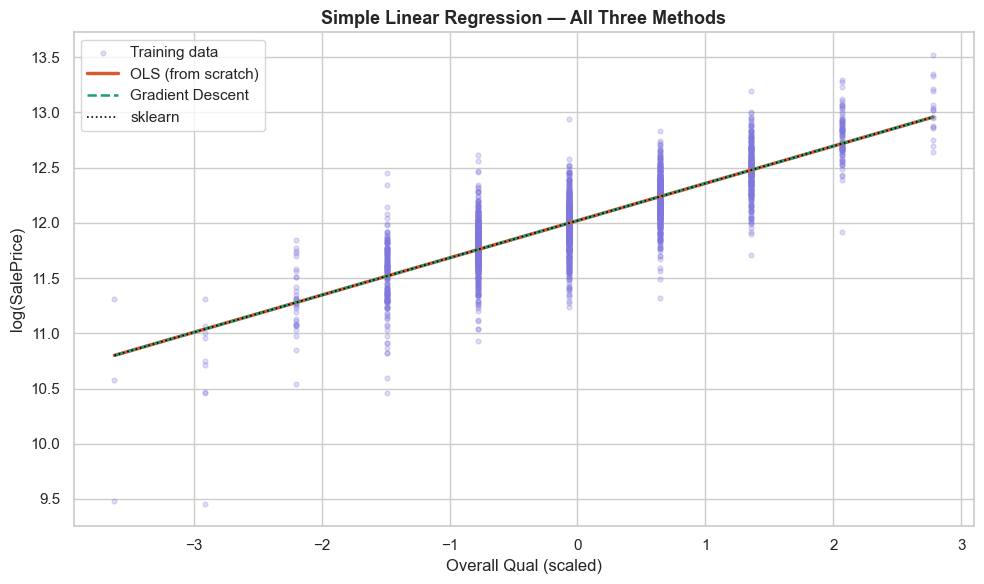

In [12]:
# Visualise all three regression lines on the same scatter plot.
# They should all overlap almost perfectly.
 
x_range = np.linspace(x_train.min(), x_train.max(), 200)
 
plt.figure(figsize=(10, 6))
 
# scatter of training data
plt.scatter(x_train, y_train, alpha=0.25, color='#7F77DD', s=12, label='Training data')
 
# OLS line
plt.plot(x_range, beta0_ols + beta1_ols * x_range,
         color='#D85A30', linewidth=2.5, label='OLS (from scratch)')
 
# GD line
plt.plot(x_range, beta0_gd + beta1_gd * x_range,
         color='#1D9E75', linewidth=1.8, linestyle='--', label='Gradient Descent')
 
# sklearn line
plt.plot(x_range, sk_model.intercept_ + sk_model.coef_[0] * x_range,
         color='black', linewidth=1.2, linestyle=':', label='sklearn')
 
plt.xlabel(f'{feature} (scaled)')
plt.ylabel('log(SalePrice)')
plt.title('Simple Linear Regression — All Three Methods', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\11_slr_regression_lines.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
 

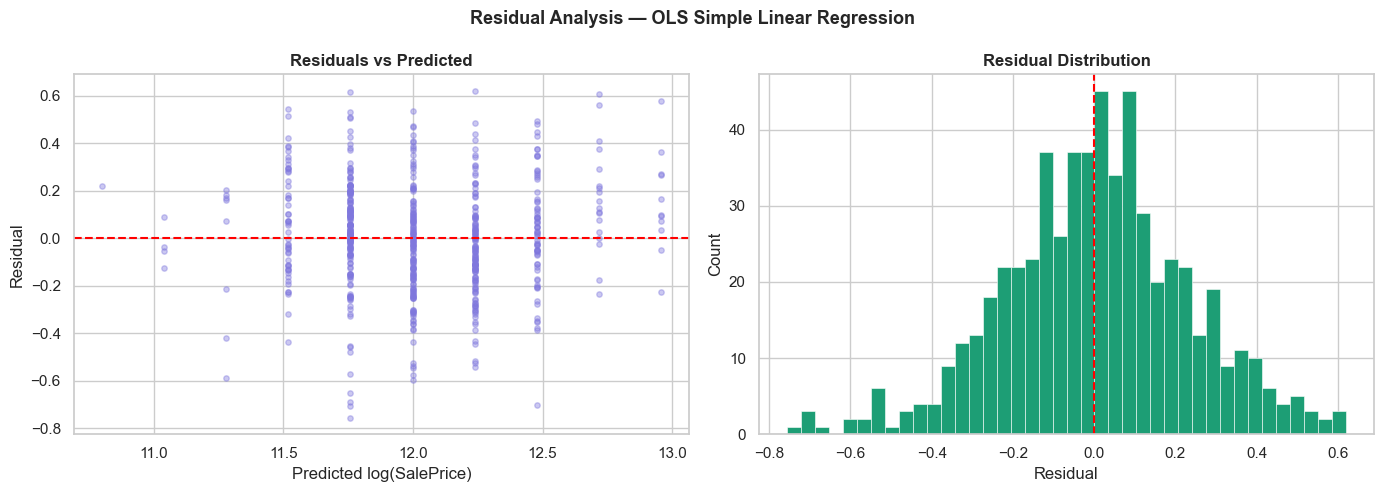

Mean of residuals : 0.004572  (should be close to 0)
Std  of residuals : 0.2311


In [13]:
# Residual = actual - predicted
# A good model has residuals randomly scattered around 0.
# If you see a pattern → the model is missing something.
 
residuals = y_test - y_pred_test_ols
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Residuals vs Predicted
axes[0].scatter(y_pred_test_ols, residuals, alpha=0.4, color='#7F77DD', s=15)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted log(SalePrice)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
 
# Plot 2: Distribution of residuals (should look like a bell curve)
axes[1].hist(residuals, bins=40, color='#1D9E75', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
 
plt.suptitle('Residual Analysis — OLS Simple Linear Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\12_slr_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
print(f"Mean of residuals : {residuals.mean():.6f}  (should be close to 0)")
print(f"Std  of residuals : {residuals.std():.4f}")
 

In [14]:
print("=" * 52)
print("         PHASE 4 COMPLETE — SUMMARY")
print("=" * 52)
print(f"\n  Feature used    : {feature}")
print(f"  Model           : ŷ = {beta0_ols:.4f} + {beta1_ols:.4f} * x")
print(f"  Test R²         : {r2_ols:.4f}  ({r2_ols:.1%} variance explained)")
print(f"  Test RMSE       : {rmse_test_ols:.4f}  (in log scale)")
print()
print("  Key learnings:")
print("  → OLS gives exact answer in one step")
print("  → Gradient Descent gives same answer iteratively")
print("  → Both match sklearn perfectly")
print(f"  → One feature alone explains {r2_ols:.1%} of price variance")
print(f"  → We need MORE features to do better → Phase 5")
print("=" * 52)
 

         PHASE 4 COMPLETE — SUMMARY

  Feature used    : Overall Qual
  Model           : ŷ = 12.0200 + 0.3371 * x
  Test R²         : 0.7026  (70.3% variance explained)
  Test RMSE       : 0.2311  (in log scale)

  Key learnings:
  → OLS gives exact answer in one step
  → Gradient Descent gives same answer iteratively
  → Both match sklearn perfectly
  → One feature alone explains 70.3% of price variance
  → We need MORE features to do better → Phase 5
